In [90]:
import warnings
warnings.filterwarnings("ignore")

In [91]:
import string
import torch
import numpy as np
import pandas as pd

from flonacomldft.utils.diagnostics import (
    avg_windows,
    R_hat
)

from flonacomldft.utils.io_utils import (
    get_project_path,
    get_path
)

import matplotlib as mlp
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
from matplotlib.transforms import Bbox
import seaborn as sns
import cmocean.cm as cmo

from flonacomldft.utils.plots import (
    load_ag6_image
)

In [92]:
sns.set()

# science format
science = {
            # Set line widths
            'axes.linewidth' : 1,
            'grid.linewidth' : 1,

            # Remove legend frame
            'legend.frameon' : False,

            # Always save as 'tight'
            'savefig.bbox' : 'tight',
            'savefig.pad_inches' : 0.1,

            # Use serif fonts
            #'font.serif' : 'Times',
            'font.family' : 'serif',
            'mathtext.fontset' : 'dejavuserif',
    
            # Set y axis
            'ytick.direction' : 'out',
            'ytick.major.size' : 3,
            'ytick.major.width' : 0.5,
            'ytick.minor.size' : 1.5,
            'ytick.minor.width' : 0.5,
            'ytick.minor.visible' : True,

            # Set x axis
            'xtick.direction' : 'out',
            'xtick.major.size' : 3,
            'xtick.major.width' : 0.5,
            'xtick.minor.size' : 1.5,
            'xtick.minor.width' : 0.5,
            'xtick.minor.visible' : True
           }

# set sns theme with science format
sns.set_theme(style='ticks', rc=science)

methods_color = dict(zip(['ab-flowMC w.o. MLP', 'ab-flowMC', 'MD', 
                        'ab-flowMM w.o. MLP', 'ab-flowMM'],
                        ['#0077BB', '#CC3311', '#cdb332',
                        '#0077BB', '#CC3311']
                        ))

sns.color_palette(methods_color.values())


[(0.0, 0.4666666666666667, 0.7333333333333333),
 (0.8, 0.2, 0.06666666666666667),
 (0.803921568627451, 0.7019607843137254, 0.19607843137254902),
 (0.0, 0.4666666666666667, 0.7333333333333333),
 (0.8, 0.2, 0.06666666666666667)]

# 1. Figure 1 - ab-flowMC

In [93]:
def set_plot_figure_1(
    isomer,
    cvs,
    mlp_predictions,
    accs_rate,
    rhat,
    colors,
    figsize=(6*3, 3*3),
    fontsize=22,
    size_axes_label=22,
    size_tick_label=22,
    size_legend=17,
    linewidth=2,
    markersize=6,
    hspace=0.6,
    wspace=0.6,
):
    
    ncols = 4
    nrows = 2

    sns.set_context("paper", rc={"font.size":fontsize,
                        "axes.titlesize":fontsize,
                        "axes.labelsize":size_axes_label,
                        "xtick.labelsize":size_tick_label,
                        "ytick.labelsize":size_tick_label,
                        "legend.fontsize":size_legend,
                        }) 

    # -- set figure --

    fig, axs = plt.subplots(ncols=ncols, 
                    nrows=nrows, 
                    figsize=figsize,
                    gridspec_kw={'wspace': wspace,
                                'hspace': hspace})

    # -- set subplots --

    gs = axs[0, 0].get_gridspec()

    for ax in axs[:2, :2].ravel():
        ax.remove()
    
    axbig = fig.add_subplot(gs[0:, :2])

    ax1 = axs[0][2]
    ax2 = axs[0][3]
    ax3 = axs[1][2]
    ax4 = axs[1][3]

    l, b, h, w = axbig.get_position().get_points().flatten()
    ax_mol = fig.add_axes([l + w*0.13, b + h*0.9, w*0.4, h*0.4])

    # -- subplot for energy --

    ax_energies = fig.add_axes([l*1.4, b*1.8, w*0.1, h*0.35])

    # -- item to subplot and delete top and right axis lines --

    for n, ax in enumerate([axbig, ax1, ax2, ax3, ax4]):
        if n==0:
            posx = -0.1
            posy = 1.05
        else:
            posx = -0.35
            posy = 1.15
        ax.text(posx,
        posy, 
        string.ascii_uppercase[n], 
        transform=ax.transAxes, 
        weight='bold')
        
        ax.spines[['right', 'top']].set_visible(False)

    axbig.spines[['right', 'top']].set_visible(False)
    ax_mol.set_axis_off()
        
    # -- plot isomer image --
    
    ax_mol.imshow(load_ag6_image(isomer))

    # -- plot cvs (density) --
    
    sns.kdeplot(
        data=cvs[cvs['Method'] == 'ab-flowMC w.o. MLP'], 
        x='C', 
        y='R',
        hue='Method',
        fill=False, 
        common_norm=False,
        linewidths=linewidth*1.1,
        linestyles='--',
        ax=axbig,
        levels=6,
        )

    # -- plot cvs (samples) -- 

    sns.scatterplot(
            data=cvs[cvs['Method'] != 'ab-flowMC w.o. MLP'],
            x='C', 
            y='R', 
            hue='Method',
            style='Method',
            ax=axbig,
            palette=colors,
            s=markersize*10,
            zorder=1,
            markers='o',
            alpha=1,
            legend=True,
        )
    
    markers = ['o', '', 'o']
    linestyles = ['', 'dashed', '']
    
    patches = [ axbig.plot([],[], 
                               marker=markers[i],  
                               linestyle=linestyles[i],
                               markersize=markersize,
                               linewidth=linewidth, 
                               color=colors[key], 
                label="{:s}".format(key) )[0]  for i, key in enumerate(cvs['Method'].unique()[:3]) ]
    
    axbig.legend(handles=patches)
    axbig.set_xlabel('Coordination number')
    axbig.set_ylabel('Radius of gyration')

    # -- plot energies --

    sns.histplot(data=cvs,
                stat='density',
                x='U',
                hue='Method',
                bins=20,
                alpha=1,
                palette=colors,
                element='step',
                linewidth=linewidth,
                fill=False,
                ax=ax_energies,
                common_bins=False, 
                common_norm=False,
                legend=False, 
                )

    #ax_energies.set_xlim(cvs['U'].min(), cvs['U'].max())

    ax_energies.set_ylabel('Density (u.a.)', fontsize=size_legend)
    ax_energies.set_xlabel('Potential energy (eV)', fontsize=size_legend)
    ax_energies.xaxis.set_tick_params(labelsize=size_legend)
    ax_energies.yaxis.set_tick_params(labelsize=size_legend)


    # -- plot MLP predictions --

    energy_max = cvs['U'].max()
    mlp_predictions = mlp_predictions[mlp_predictions['True values'] < energy_max]  

    palette_predictions = dict(zip(['Train', 'Test'], 
                                    ['#8f230b', '#f27e64']
                                    ))
    
    points = {'x': np.array([mlp_predictions['True values'].min(),
                  energy_max-0.05]),
            'y': np.array([mlp_predictions['True values'].min(), 
                  energy_max-0.05])}
    
    sns.lineplot(points,
                x='x',
                y='y',
                linestyle='--',
                color='k',
                linewidth=linewidth,
                ax=ax1,)

    sns.scatterplot(data=mlp_predictions,
                x='True values',
                y='Predictions',
                hue='Dataset',
                style='Dataset',
                markers=['p', 'X'],
                palette=palette_predictions,
                s=markersize*10,
                zorder=2.5,
                ax=ax1)

    handles, labels = ax1.get_legend_handles_labels()
    ax1.legend(handles=handles, labels=['Train', 'Test'], fontsize=size_legend*0.75)

    ax1.set_xlabel('Potential energy (eV)')
    ax1.set_ylabel('Predictions (eV)')

    # -- plot accs --

    accs_rate_avg = []

    for simulation in accs_rate['Method'].unique():
        df = accs_rate[accs_rate['Method'] == simulation]
        df_new = pd.DataFrame(columns=accs_rate.columns)
    
        df_new['Acceptance Rate'] = avg_windows(
            df['Acceptance Rate'], 
            window_size=40, 
            axis=1)
        df_new['Step'] = avg_windows(
            df['Step'],
            window_size=40, 
            axis=1)
        df_new['Method'] = simulation
        df_new['Isomer'] = accs_rate['Isomer'].unique()[0]
        accs_rate_avg.append(df_new)
    
    accs_rate_avg = pd.concat(accs_rate_avg)
    
    sns.lineplot(accs_rate, 
                x='Step', 
                y='Acceptance Rate', 
                hue='Method',
                palette=methods_color, 
                alpha=0.1,
                ax=ax2,
                legend=False) 
    
    sns.lineplot(accs_rate_avg,
                x='Step', 
                y='Acceptance Rate', 
                hue='Method',
                palette=methods_color, 
                linewidth=linewidth,
                ax=ax2,
                legend=False)

    ax2.set_ylabel("Acceptance rate")
    ax2.set_xlabel("Steps")
            

    # -- plot rhat steps and time --

    markers = ['o', 's', '^']
    linestyles = ['dashed', 'dotted', '-']
    labels = ['Coordination \n number', 'Radius \n of gyration', 'Potential \n energy']
    columns = ['C', 'R', 'U']
            
    for key in rhat['Method'].unique():
        df = rhat[rhat['Method'] == key]
        for i in range(3):
            sns.lineplot(df,
                        x='MCMC step', 
                        y=columns[i], 
                        linestyle=linestyles[i], 
                        marker=markers[i],
                        markersize=markersize*1.4,
                        linewidth=linewidth,
                        color=colors[key], 
                        label=labels[i],
                        ax=ax3,
                        legend=False)
            
            sns.lineplot(df,
                        x='Time (h)', 
                        y=columns[i], 
                        linestyle=linestyles[i], 
                        marker=markers[i],
                        markersize=markersize*1.4,
                        linewidth=linewidth,
                        color=colors[key], 
                        label=labels[i],
                        ax=ax4,
                        legend=False)
    
    ax3.axhline(1.01, c='grey', ls='--', 
                  linewidth=linewidth)

    ax3.set_xlabel('Steps')
    ax3.set_ylabel(r'$\hat{R}$')

    ax4.axhline(1.01, c='grey', ls='--', 
                  linewidth=linewidth)

    ax4.set_xlabel('Time (h)')
    ax4.set_ylabel(r'$\hat{R}$')

    # -- plot rhat legend --

    patches = [ ax3.plot([],[], 
                               marker=markers[i], 
                               linestyle=linestyles[i], 
                               linewidth=linewidth, 
                               markersize=markersize, 
                               color='black', 
                label="{:s}".format(labels[i]) )[0]  for i in range(3) ]
    
    patches = patches + [ ax3.plot([],[],  
                               linestyle='dashed', 
                               linewidth=linewidth, 
                               color='gray', 
                label="{:s}".format('Threshold \n 1.01') )[0] ]
    
    ax3.legend(handles=patches, fontsize=size_legend*0.75)

    # -- set formatter axis --
 
    axbig.xaxis.set_major_locator(plt.MaxNLocator(4))
    axbig.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
    axbig.yaxis.set_major_locator(plt.MaxNLocator([4, 2][isomer]))
    axbig.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
#
    #ax1.xaxis.set_major_locator(plt.MaxNLocator(4))
    ax1.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
    #ax1.yaxis.set_major_locator(plt.MaxNLocator(4))
    ax1.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
#
    #ax2.yaxis.set_major_locator(plt.MaxNLocator(4))
    ax2.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
#
    #ax3.xaxis.set_major_locator(plt.MaxNLocator(4))
    ax3.xaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))
    #ax3.yaxis.set_major_locator(plt.MaxNLocator(4))
    ax3.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
#
    #ax4.xaxis.set_major_locator(plt.MaxNLocator(4))
    ax4.xaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))
    #ax4.yaxis.set_major_locator(plt.MaxNLocator(4))
    ax4.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))


    

In [94]:
path_datasets = get_project_path() + '/database/andersen/datasets'
path_results = get_project_path() + '/figures/preprint_v2/data'
path_save_figures = get_project_path() + '/figures/preprint_v2/plots'

In [95]:
N_input_samples = 500

md_samples_is0 = pd.read_csv(path_datasets + '/is0_flow_train.csv').rename(
            columns={'potential_energy': 'U'})[:N_input_samples][['U', 'C', 'R']]
md_samples_is0['Isomer'] = 0
md_samples_is0['Method'] = 'MD'

md_samples_is1 = pd.read_csv(path_datasets + '/is1_flow_train.csv').rename(
            columns={'potential_energy': 'U'})[:N_input_samples][['U', 'C', 'R']]
md_samples_is1['Isomer'] = 1
md_samples_is1['Method'] = 'MD'

md_samples = pd.concat([md_samples_is0, md_samples_is1])
mcmc_samples = pd.read_csv(path_results + '/cvs_potential_energy.csv')
accs_rates = pd.read_csv(path_results + '/acceptance_rates.csv')
rhat_values = pd.read_csv(path_results + '/rhat.csv')
mlp_datasets = pd.read_csv(path_results + '/mlp_datasets.csv')

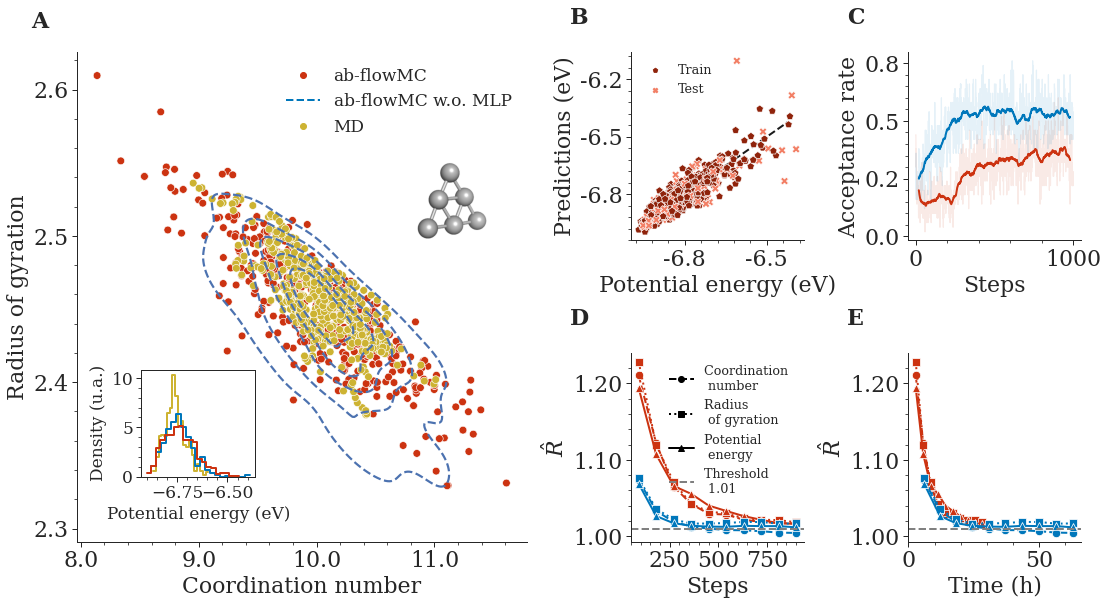

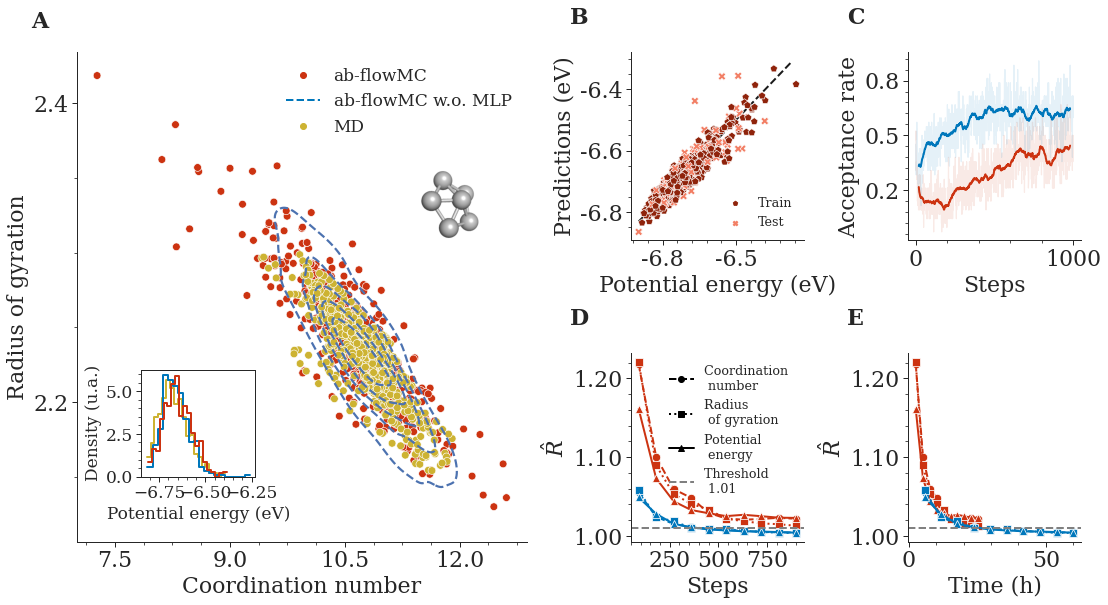

In [96]:
np.random.seed(42)

for isomer in [0, 1]:

    md = md_samples[md_samples['Isomer'] == isomer]
    abflowmc = mcmc_samples[mcmc_samples['Method'] == 'ab-flowMC']
    abflowmc = abflowmc[abflowmc['Isomer'] == isomer]
    abflowmc_womlp = mcmc_samples[mcmc_samples['Method'] == 'ab-flowMC w.o. MLP']
    abflowmc_womlp = abflowmc_womlp[abflowmc_womlp['Isomer'] == isomer]

    cvs = pd.concat([
        abflowmc.sample(N_input_samples),
        abflowmc_womlp.sample(N_input_samples),
        md,
    ])

    mlp_predictions = mlp_datasets[
        mlp_datasets['Isomer'] == isomer
        ].sample(N_input_samples*2)

    accs_rate = accs_rates[accs_rates['Isomer'] == isomer]

    rhat = rhat_values[rhat_values['Isomer'] == isomer]

    set_plot_figure_1(
                    isomer=isomer,
                    cvs=cvs,
                    mlp_predictions=mlp_predictions,
                    accs_rate=accs_rate,
                    rhat=rhat, 
                    colors=methods_color)
    
    plt.savefig(path_save_figures + f'/figure_ab-flowMC_isomer_{isomer}.pdf', bbox_inches='tight')